# **When Consumers Misjudge Privacy Costs**
**Master's Thesis in Economics June 2026**

# Table of contents
* [Imports and Set Magic](#toc0_)   

* [1 Calibrating Equilibria for Varying epsilon and s](#toc1_) 

* [2 Functions of Epsilon](#toc2_)    

* [3 Functions of s](#toc3_)    

* [4 Introducing Naïveté](#toc4_)   

* [5 Welfare Comparisons](#toc5_) 

* [6: Symmetric Case](#toc6_) 

## <a id='toc0_'></a>[Imports and Set Magic](#toc0_)

In [1]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.optimize import minimize_scalar

In [2]:
# Set magics
# use autoreload to only reload the user-written functions 
%load_ext autoreload
%autoreload 1

%aimport model 
%aimport nosharing
%aimport testsym
# %aimport vareps
# %aimport baseline
# ^can be taken into usee when needed; they're in a separate folder, need to be taken out first


General Parameter values

In [ ]:
eps_grid = np.linspace(0.0, 0.5, 25)   # preference strength
s_grid   = np.linspace(0.001, 0.2, 25) # search cost (avoid 0 exactly)
prev_p1, prev_p2 = 0.5, 0.5
sigma = 0.5

## <a id='toc1_'></a>[1 Calibrating Equilibria for Varying epsilon and s](#toc1_)

In [ ]:
mu = 0.75
gamma = 0
results_vareps = model.equilibrium_path_s_eps(eps_grid, s_grid, gamma, mu, sigma, prev_p1, prev_p2)
df_vareps = pd.DataFrame(results_vareps)

In [ ]:
model.plot_colorblock(df_vareps, eps_grid, s_grid)

In [5]:
eps_grid = np.linspace(0.0, 0.5, 25)   # preference strength
s_grid   = np.linspace(0.001, 0.5, 25) # search cost (avoid 0 exactly)
prev_p1, prev_p2 = 0.5, 0.5
mu = 0.75
sigma = 0.5
gamma = 0

In [8]:
results_highs = model.equilibrium_path_s_eps(eps_grid, s_grid, gamma, mu, sigma, prev_p1, prev_p2)
df_highs = pd.DataFrame(results_highs)

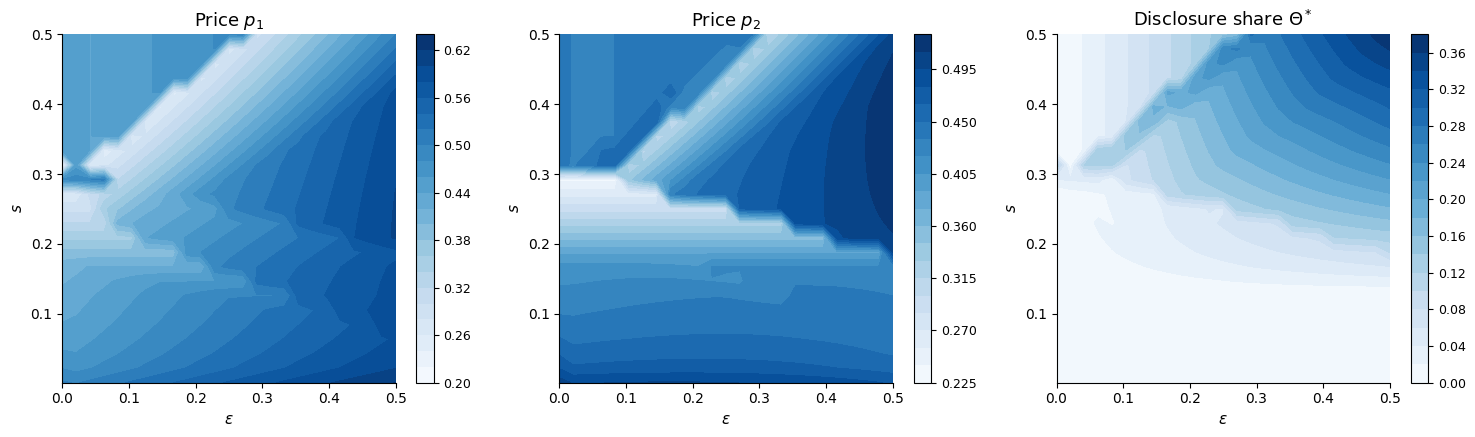

In [9]:
model.plot_colorblock(df_highs, eps_grid, s_grid)

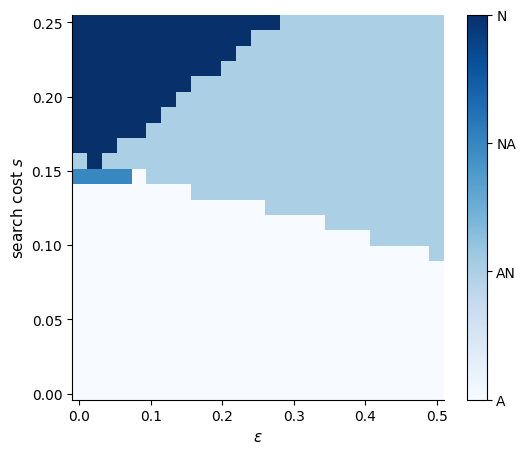

In [68]:
mixed_highs = model.find_mixed_regions(df_highs)
model.plot_regime_map(df_highs, eps_grid, s_grid)

## <a id='toc2_'></a>[2 Functions of Epsilon](#toc2_)

In [34]:
# Shared parameters
eps_grid = np.linspace(0.1, 0.5, 25)
s_values = [0.1, 0.15, 0.25]
p1_init, p2_init = 0.5, 0.5

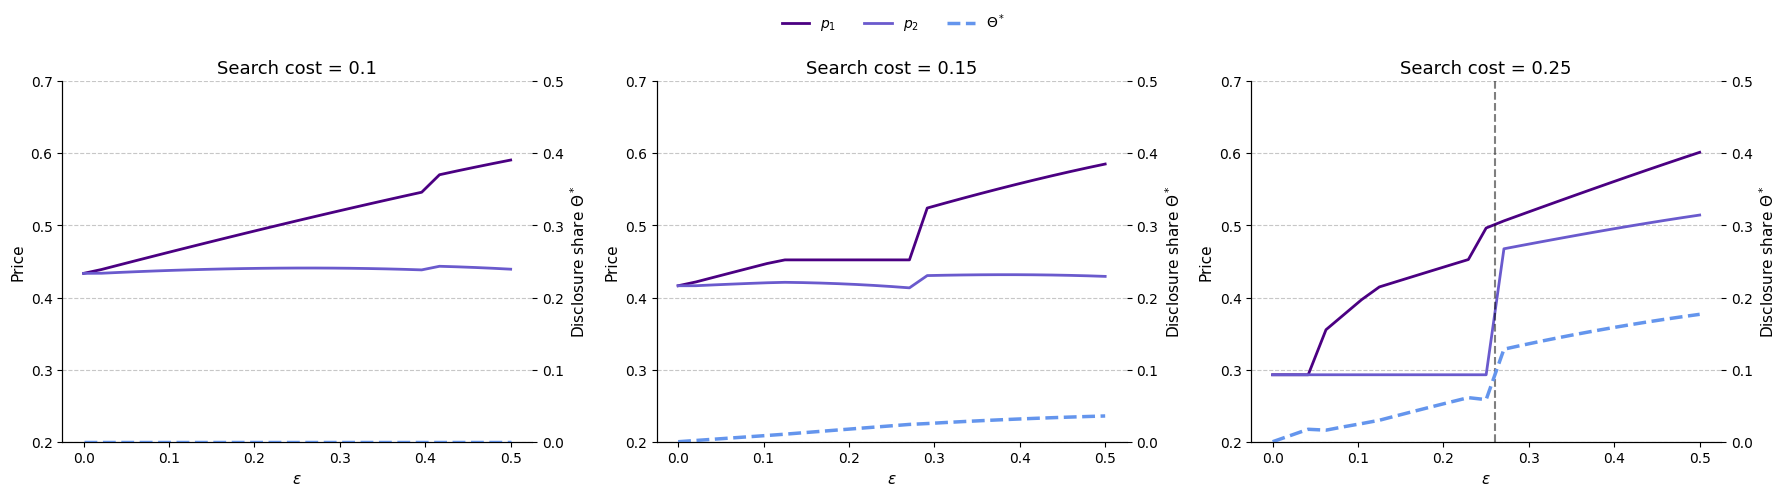

In [106]:
# baseline
gamma = 0
mu = 0.75
model.plot_price_curves(eps_grid, s_values, gamma, mu, sigma, p1_init, p2_init)

## <a id='toc3_'></a>[3 Functions of s](#toc3_)

In [36]:
# Shared parameters
s_grid = np.linspace(0.001, 0.25, 25)
eps_values = [0.3, 0.4, 0.5]
p1_init, p2_init = 0.5, 0.5

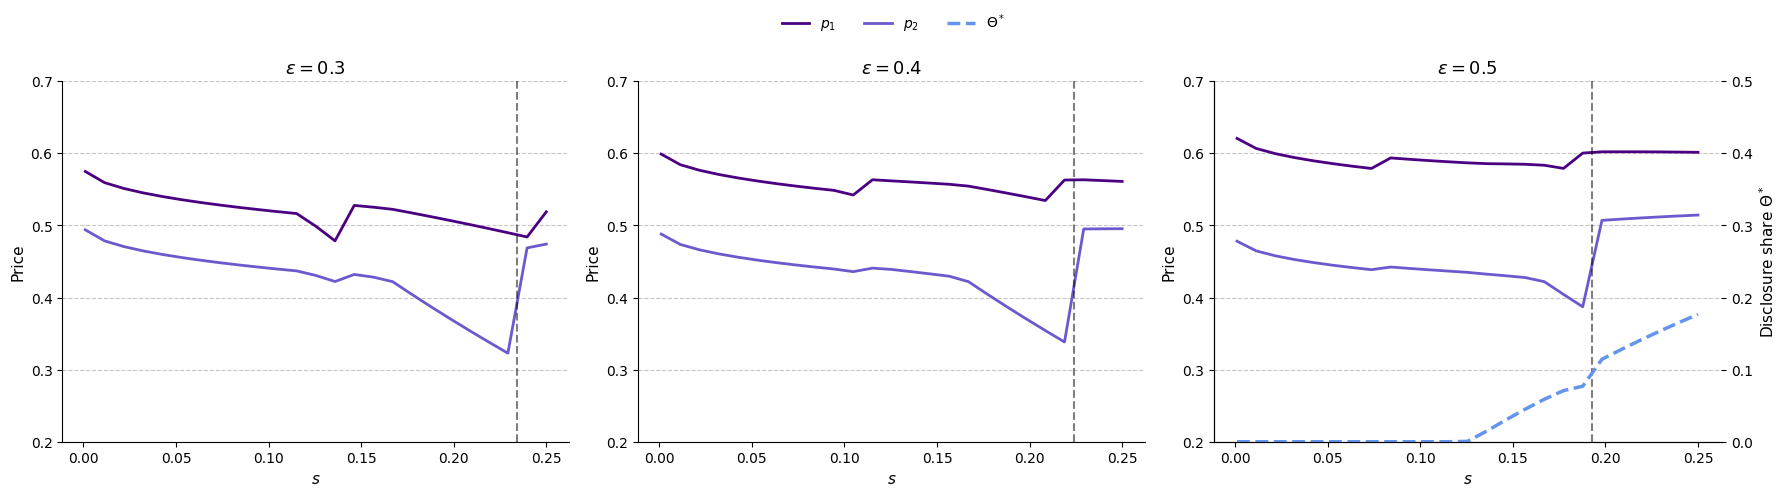

In [107]:
gamma = 0
mu = 0.75
model.plot_price_curves_s(s_grid, eps_values, gamma, mu, sigma, p1_init, p2_init)

# Welfare comparison

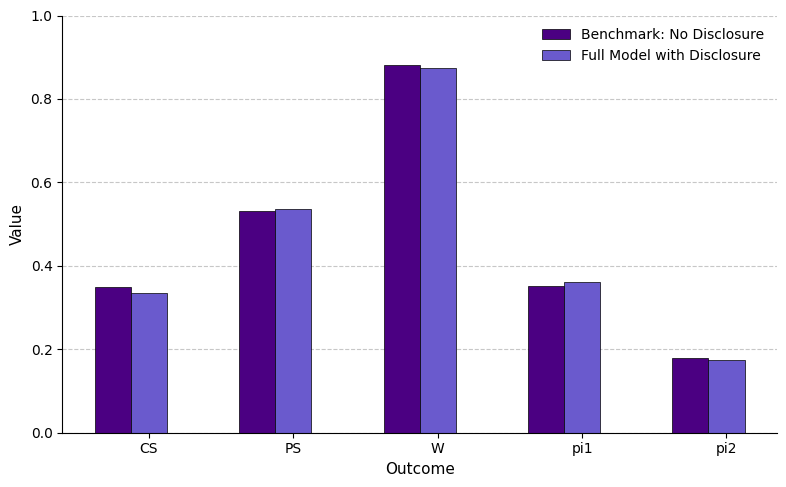

In [78]:
df_compare_AN = model.compare_outcomes_benchmark(eps=0.5, s=0.25, mu=0.75, sigma=0.5)
model.plot_welfare_comparison(df_compare_AN)

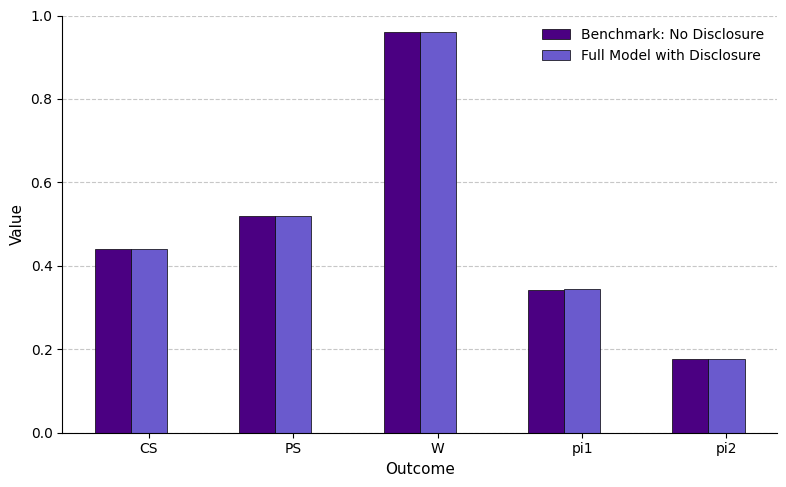

In [79]:
df_compare_A = model.compare_outcomes_benchmark(eps=0.5, s=0.15, mu=0.75, sigma=0.5)
model.plot_welfare_comparison(df_compare_A)

In [83]:
print(df_compare_AN.head(round(3)))

                                  p1        p2       pi1       pi2        CS  \
Benchmark: No Disclosure    0.583867  0.508031  0.352513  0.179887  0.348949   
Full Model with Disclosure  0.601519  0.514479  0.362406     0.175  0.335757   

                                  PS         W    Theta regime  
Benchmark: No Disclosure      0.5324  0.881349        0     AN  
Full Model with Disclosure  0.537406  0.873163  0.17675     AN  


In [84]:
print(df_compare_A.head(round(3)))

                                  p1        p2       pi1       pi2        CS  \
Benchmark: No Disclosure    0.583737  0.431217  0.342556  0.176885  0.441092   
Full Model with Disclosure  0.585265  0.429379  0.343851  0.176016  0.440855   

                                  PS         W     Theta regime  
Benchmark: No Disclosure    0.519441  0.960533         0      A  
Full Model with Disclosure  0.519867  0.960722  0.035725      A  


## <a id='toc4_'></a>[4 Introducing Naïveté](#toc4_)

In [15]:
# Define parameter cases #
gamma_grid = np.linspace(0, 1, 50)

cases = [
    (0.4, 0.1),
    (0.4, 0.13),
    (0.5, 0.16),
    (0.5, 0.2)
]

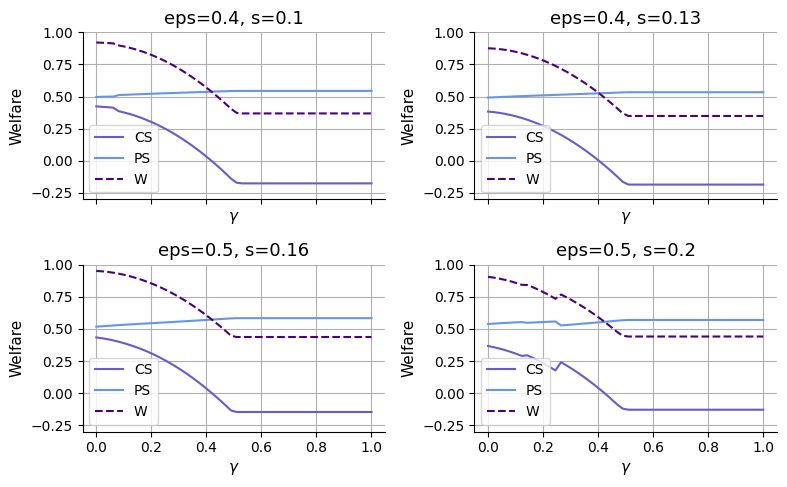

In [16]:
# variable epsilon with naïvete
mu = 0.75
fig, axes = plt.subplots(2, 2, figsize=(8, 5), sharex=True)

for ax, (eps, s) in zip(axes.flatten(), cases):
    
    p1, p2, pi1, pi2, theta, CS, PS, W = model.compute_equilibrium_path(eps, s, gamma_grid, mu, sigma)
    ax.plot(gamma_grid, CS, label="CS", color="slateblue")
    ax.plot(gamma_grid, PS, label="PS", color="cornflowerblue")
    ax.plot(gamma_grid, W, linestyle="--", label="W", color="indigo")
    
    ax.set_title(f"eps={eps}, s={s}")
    ax.set_xlabel(r"$\gamma$")
    ax.set_ylabel("Welfare")
    ax.set_ylim(-0.3,1)
    ax.legend()
    ax.grid(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


plt.tight_layout()
plt.show()

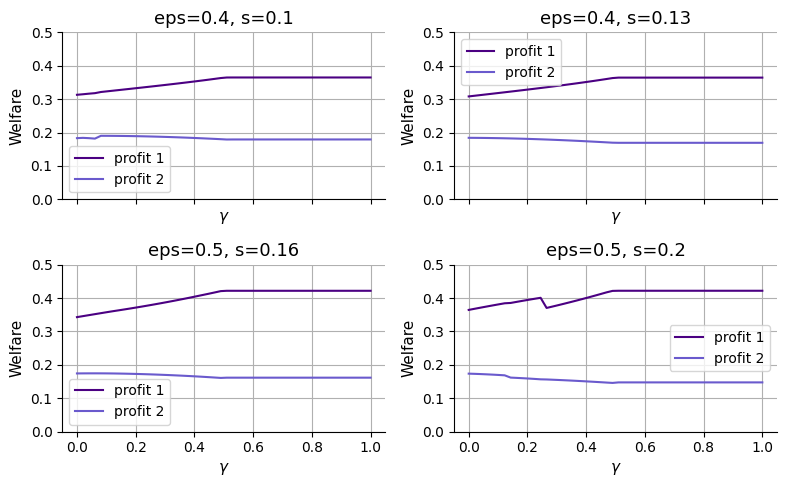

In [17]:
# variable epsilon with naïvete
mu = 0.75
fig, axes = plt.subplots(2, 2, figsize=(8, 5), sharex=True)

for ax, (eps, s) in zip(axes.flatten(), cases):
    
    p1, p2, pi1, pi2, theta, CS, PS, W = model.compute_equilibrium_path(eps, s, gamma_grid, mu, sigma)
    ax.plot(gamma_grid, pi1, label="profit 1", color="indigo")
    ax.plot(gamma_grid, pi2, label="profit 2", color= "slateblue")
    
    ax.set_title(f"eps={eps}, s={s}")
    ax.set_xlabel(r"$\gamma$")
    ax.set_axisbelow(True)
    ax.set_ylabel("Welfare")
    ax.legend()
    ax.set_ylim(0, 0.5)
    ax.grid(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## <a id='toc5_'></a>[5 Welfare Outcomes](#toc5_)

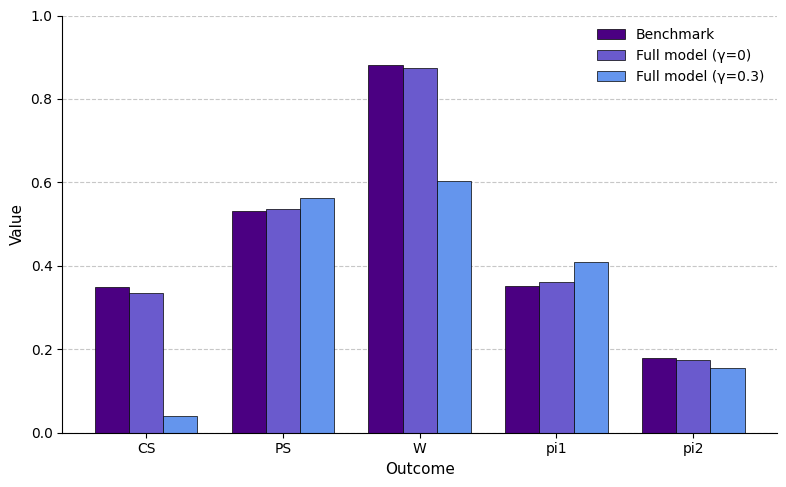

In [92]:
df_comp_naive_AN = model.compare_outcomes(eps=0.5, s=0.25, mu=0.75, sigma=0.5)
model.plot_welfare_comparison(df_comp_naive_AN)

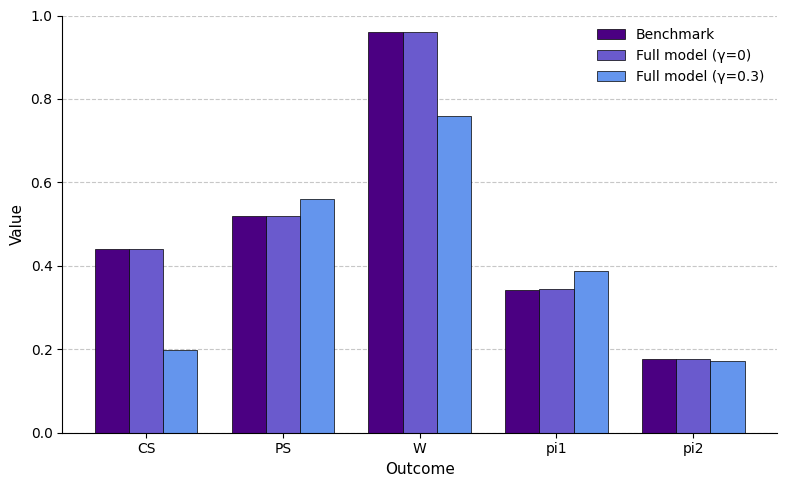

In [94]:
df_comp_naive_A = model.compare_outcomes(eps=0.5, s=0.15, mu=0.75, sigma=0.5)
model.plot_welfare_comparison(df_comp_naive_A)

In [95]:
print(df_comp_naive_AN.round(3))

                          p1        p2       pi1       pi2        CS  \
Benchmark           0.583867  0.508031  0.352513  0.179887  0.348949   
Full model (γ=0)    0.601519  0.514479  0.362406     0.175  0.335757   
Full model (γ=0.3)   0.70046  0.627337  0.408184  0.154552  0.039458   

                          PS         W     Theta regime  
Benchmark             0.5324  0.881349         0     AN  
Full model (γ=0)    0.537406  0.873163   0.17675     AN  
Full model (γ=0.3)  0.562736  0.602194  0.734757     AN  


In [96]:
print(df_comp_naive_A.round(3))

                          p1        p2       pi1       pi2        CS  \
Benchmark           0.583737  0.431217  0.342556  0.176885  0.441092   
Full model (γ=0)    0.585265  0.429379  0.343851  0.176016  0.440855   
Full model (γ=0.3)   0.67771  0.442728  0.387571   0.17299  0.197977   

                          PS         W     Theta regime  
Benchmark           0.519441  0.960533         0      A  
Full model (γ=0)    0.519867  0.960722  0.035725      A  
Full model (γ=0.3)  0.560561  0.758538   0.61885      A  


## <a id='toc6_'></a>[6 Symmetric Case](#toc6_)

In [21]:
eps_grid = np.linspace(0.0, 0.5, 25)   # preference strength
s_grid = np.linspace(0.001, 0.2, 25) # search cost (avoid 0 exactly)
gamma = 0
mu = 0.5
sigma = 0.5
prev_p1, prev_p2 = 0.5, 0.5
results_sym = model.equilibrium_path_s_eps(eps_grid, s_grid, gamma, mu, sigma, prev_p1, prev_p2)
df_sym = pd.DataFrame(results_sym)

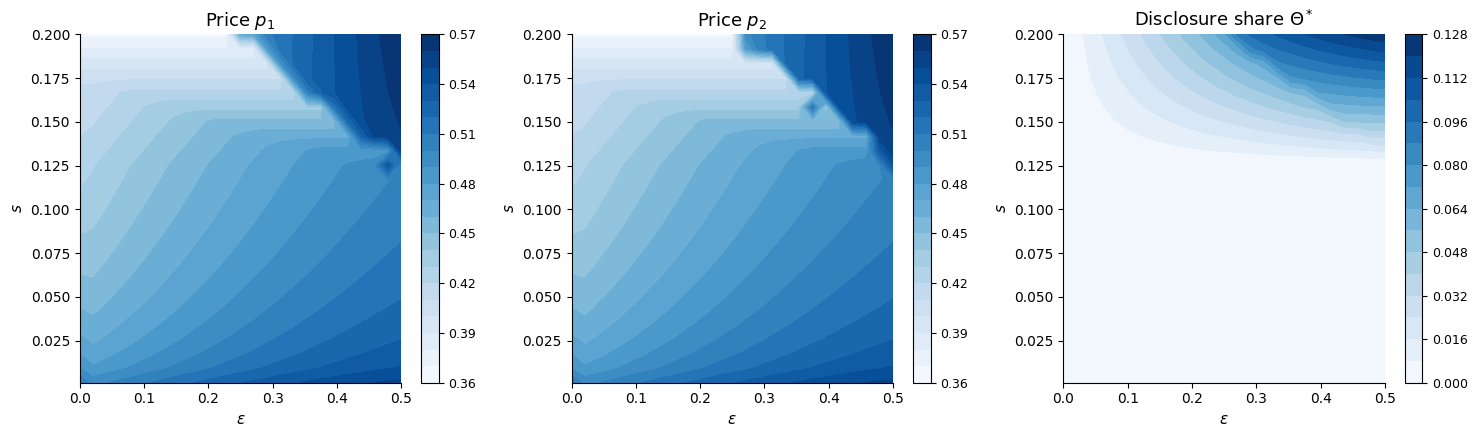

In [25]:
model.plot_colorblock(df_sym, eps_grid, s_grid)

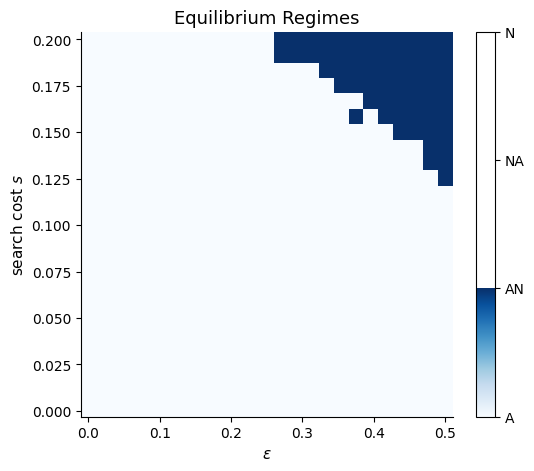

In [24]:
mixed_sym = model.find_mixed_regions(df_sym)
model.plot_regime_map(df_sym, eps_grid, s_grid)

In [27]:
df_sym = model.compare_outcomes(eps=0.5, s=0.2, mu=0.5, sigma=0.5)
print(df_sym.round(3))

                       p1        p2       pi1       pi2        CS        PS  \
No Sharing       0.552765  0.552765  0.267355  0.267355   0.38609  0.534711   
Sharing (γ=0)     0.56891   0.56891  0.271104  0.271104  0.370435  0.542207   
Sharing (γ=0.3)  0.677317  0.677317  0.283266  0.283266  0.074014  0.566532   

                        W     Theta regime  
No Sharing       0.920801         0     AN  
Sharing (γ=0)    0.912643  0.126058     AN  
Sharing (γ=0.3)  0.640546  0.697583     AN  


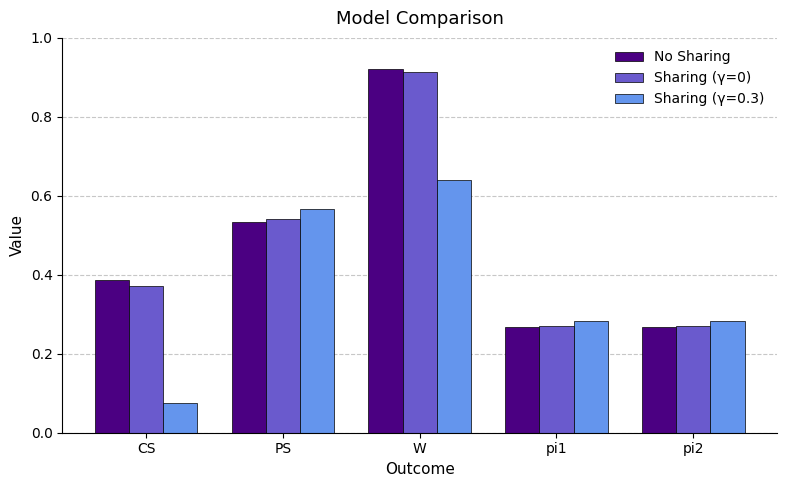

In [28]:
model.plot_welfare_comparison(df_sym)